In [1]:
import astropy.units as u

from astropy.coordinates import SkyCoord
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import frames

/home/daniel/anaconda3/envs/sunpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Para descargar datos desde JSOC necesitamos un correo
# previamente registrado/validado en JSOC.
jsoc_email = "darodriguezto@unal.edu.co"

In [3]:
# Muestra los valores conocidos para el atributo Series
# del cliente JSOC.
a.jsoc.Series
print(a.jsoc.Series)

sunpy.net.jsoc.attrs.Series

The JSOC Series to Download.

          Attribute Name           ...
---------------------------------- ...
aia_flatfield                      ...
aia_lev1                           ...
aia_lev1_euv_12s                   ...
aia_lev1_uv_24s                    ...
aia_lev1_vis_1h                    ...
aia_master_pointing3h              ...
aia_response                       ...
aia_temperature_summary_300s       ...
hmi_b_135s                         ...
hmi_b_5760s                        ...
hmi_b_720s                         ...
hmi_b_720s_dcon                    ...
hmi_b_720s_dcons                   ...
hmi_b_720s_e15w1332_cea            ...
hmi_b_720s_e15w1332_cutout         ...
hmi_b_90s                          ...
hmi_b_synoptic                     ...
hmi_b_synoptic_small               ...
hmi_bharp_720s                     ...
hmi_bharp_720s_nrt                 ...
hmi_bmap_lowres_latlon_720s        ...
hmi_c_avg120                       ...
hmi_c

In [4]:
continuum_series = "hmi.Ic_45s"  # Continuum intensity
mag_series       = "hmi.M_45s"   # LOS magnetogram
doppler_series   = "hmi.V_45s"   # Doppler velocity

In [5]:
# Intervalo temporal que queremos explorar.
time = a.Time(
    "2014-10-24 11:00:00",
    "2014-10-24 13:00:00"
)

In [6]:
query_continuum = Fido.search(
    time,
    a.jsoc.Series("hmi.Ic_45s")
)

query_continuum

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_11:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:01:30_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:02:15_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:03:00_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:03:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:04:30_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:05:15_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:06:00_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:06:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156


In [7]:
query = Fido.search(
    time,

    a.jsoc.Series("hmi.Ic_45s")
    |
    a.jsoc.Series("hmi.M_45s")
    |
    a.jsoc.Series("hmi.V_45s")
)

query

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_11:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:01:30_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:02:15_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:03:00_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:03:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:04:30_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:05:15_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:06:00_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:06:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156


In [9]:
query_sampled = Fido.search(
    time,
    a.Sample(30 * u.min),

    a.jsoc.Series("hmi.Ic_45s")
    |
    a.jsoc.Series("hmi.M_45s")
    |
    a.jsoc.Series("hmi.V_45s"),

    a.jsoc.Notify(jsoc_email)
)

query_sampled

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_11:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:30:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_12:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_12:30:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_13:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_11:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_11:30:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156


In [10]:
time_short = a.Time(
    "2014-10-24 12:00:00",
    "2014-10-24 12:01:00"
)

query_short = Fido.search(
    time_short,

    a.jsoc.Series("hmi.Ic_45s")
    |
    a.jsoc.Series("hmi.M_45s")
    |
    a.jsoc.Series("hmi.V_45s"),

    a.jsoc.Notify(jsoc_email)
)

query_short

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_12:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_12:01:30_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_12:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_12:01:30_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_12:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156


In [17]:
download_dir ="../03_Datos/"
files = Fido.fetch(
    query_short,
    path=download_dir + "/{file}"
)
files

Export request pending. [id=JSOC_20260930_000230, status=2]
Waiting for 0 seconds...
2 URLs found for download. Full request totalling 31MB
Export request pending. [id=JSOC_20260930_000231, status=2]
Waiting for 0 seconds...
2 URLs found for download. Full request totalling 32MB
Export request pending. [id=JSOC_20260930_000235, status=2]
Waiting for 0 seconds...
2 URLs found for download. Full request totalling 35MB


Files Downloaded:   0%|                                 | 0/6 [00:00<?, ?file/s]
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   0%| | 0.00/16.3M [00:00<?, ?B
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   0%| | 1.02k/16.3M [00:00<3:53
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   0%| | 33.4k/16.3M [00:01<06:1
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   1%| | 99.0k/16.3M [00:01<02:0
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   1%| | 214k/16.3M [00:01<00:55
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   3%| | 443k/16.3M [00:01<00:25
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   6%| | 902k/16.3M [00:01<00:11
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:  11%| | 1.82M/16.3M [00:01<00:0
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:  21%|▏| 3.44M/16.3M [00:01<00:0
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:  26%|▎| 4.23M/16.3M [00:02<00:0
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:  40%|▍| 6.47M/16.3M [00:02<00:0
hmi.ic_45s.20141024_120045_T

hmi.v_45s.20141024_120130_TAI.2.Dopplergram.fits:  90%|▉| 16.5M/18.3M [00:03<00:
hmi.v_45s.20141024_120130_TAI.2.Dopplergram.fits:  97%|▉| 17.7M/18.3M [00:03<00:
Files Downloaded: 100%|█████████████████████████| 6/6 [00:22<00:00,  3.74s/file]


['../03_Datos/hmi.ic_45s.20141024_120045_TAI.2.continuum.fits', '../03_Datos/hmi.ic_45s.20141024_120130_TAI.2.continuum.fits', '../03_Datos/hmi.m_45s.20141024_120045_TAI.2.magnetogram.fits', '../03_Datos/hmi.m_45s.20141024_120130_TAI.2.magnetogram.fits', '../03_Datos/hmi.v_45s.20141024_120045_TAI.2.Dopplergram.fits', '../03_Datos/hmi.v_45s.20141024_120130_TAI.2.Dopplergram.fits']

In [21]:
import glob
import sunpy.map

continuum_files = glob.glob("../03_Datos/*ic*")

continuum_map = sunpy.map.Map(continuum_files[0])
print(continuum_map.data.shape)
print(continuum_map.date)
print(continuum_map.instrument)

(4096, 4096)
2014-10-24T11:59:44.900
HMI FRONT2


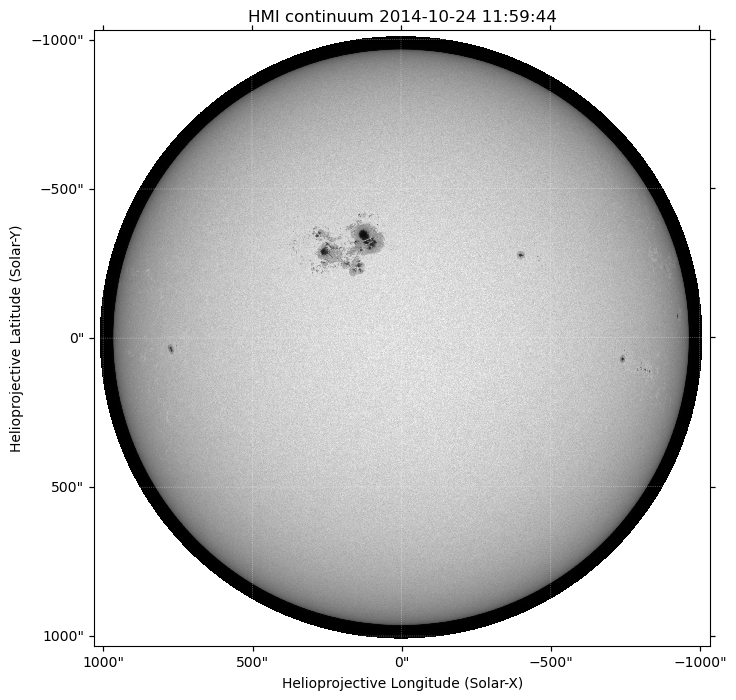

In [22]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))

# Creamos unos ejes utilizando el sistema de coordenadas del mapa
ax = fig.add_subplot(projection=continuum_map)

# Dibujamos la observación
continuum_map.plot(axes=ax)

plt.show()

## Downloading a smaller region

In [12]:
# Coordenada inferior izquierda de nuestra región.
bottom_left = SkyCoord(
    -500 * u.arcsec,
    -500 * u.arcsec,
    frame=frames.Helioprojective,
    observer="earth",
    obstime="2014-10-24 12:00:00"
)

# Coordenada superior derecha.
top_right = SkyCoord(
    0 * u.arcsec,
    100 * u.arcsec,
    frame=frames.Helioprojective,
    observer="earth",
    obstime="2014-10-24 12:00:00"
)

In [13]:
# Definimos el recorte que queremos que JSOC haga
# antes de enviarnos los datos.
cutout = a.jsoc.Cutout(
    bottom_left,
    top_right=top_right,
    tracking=False
)

In [14]:
query_cutout = Fido.search(

    # Cuándo queremos observar.
    a.Time(
        "2014-10-24 12:00:00",
        "2014-10-24 12:01:00"
    ),

    # Qué producto queremos.
    a.jsoc.Series("hmi.Ic_45s"),

    # Correo registrado en JSOC necesario para exportar.
    a.jsoc.Notify(jsoc_email),

    # Qué región espacial queremos descargar.
    cutout
)

query_cutout

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str23,str7,str10,float64,int64
2014.10.24_12:00:45_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156
2014.10.24_12:01:30_TAI,SDO/HMI,HMI_FRONT2,6173.0,2156


In [26]:
download_cut= download_dir +"/cut/"
files_cutout = Fido.fetch(query_cutout, path=download_cut + "/{file}")

files_cutout

Export request pending. [id=JSOC_20260930_000262, status=2]
Waiting for 0 seconds...
2 URLs found for download. Full request totalling 3MB


Files Downloaded:   0%|                                 | 0/2 [00:00<?, ?file/s]
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   0%| | 0.00/1.69M [00:00<?, ?B
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   0%| | 1.02k/1.69M [00:00<25:3
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   2%| | 33.4k/1.69M [00:01<00:3
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:   6%| | 99.0k/1.69M [00:01<00:1
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:  13%|▏| 214k/1.69M [00:01<00:05
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:  26%|▎| 443k/1.69M [00:01<00:02
hmi.ic_45s.20141024_120045_TAI.2.continuum.fits:  53%|▌| 902k/1.69M [00:01<00:00
Files Downloaded:  50%|████████████▌            | 1/2 [00:02<00:02,  2.70s/file]
hmi.ic_45s.20141024_120130_TAI.2.continuum.fits:   0%| | 0.00/1.69M [00:00<?, ?B
hmi.ic_45s.20141024_120130_TAI.2.continuum.fits:   0%| | 1.02k/1.69M [00:00<27:1
hmi.ic_45s.20141024_120130_TAI.2.continuum.fits:   2%| | 33.4k/1.69M [00:01<00:4
hmi.ic_45s.20141024_120130_T

['../03_Datos/cut/hmi.ic_45s.20141024_120045_TAI.2.continuum.fits', '../03_Datos/cut/hmi.ic_45s.20141024_120130_TAI.2.continuum.fits']

In [27]:
cutout_map = sunpy.map.Map(files_cutout[0])

print("Shape:", cutout_map.data.shape)
print("Date:", cutout_map.date)
print("Instrument:", cutout_map.instrument)

Shape: (1190, 992)
Date: 2014-10-24T11:59:44.900
Instrument: HMI FRONT2


In [28]:
print("Full disk:", continuum_map.data.shape)
print("Cutout:   ", cutout_map.data.shape)

Full disk: (4096, 4096)
Cutout:    (1190, 992)


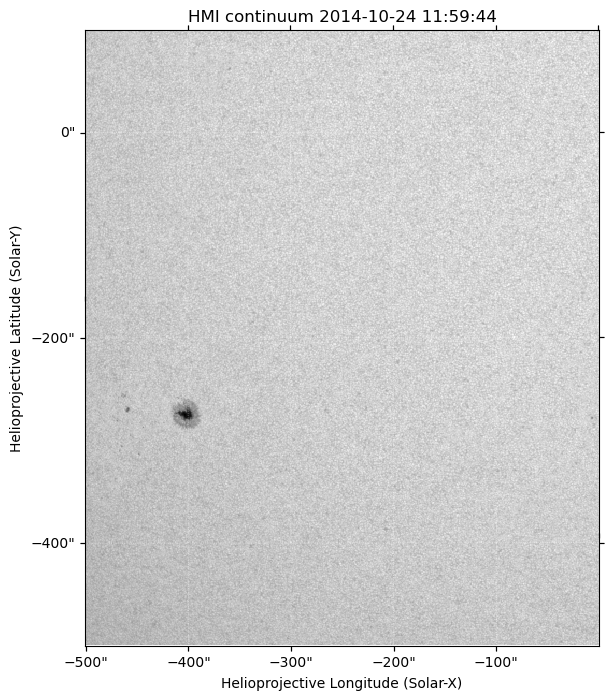

In [29]:
import sunpy.map
import matplotlib.pyplot as plt

# Creamos un SunPy Map con el FITS recortado
cutout_map = sunpy.map.Map(files_cutout[0])

# Creamos la figura usando el WCS del propio mapa
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=cutout_map)

# Graficamos el recorte
cutout_map.plot(axes=ax)

plt.show()